In [3]:
# notebooks/shap-explainability.ipynb
import os
import sys
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Ensure Python can see your 'src' folder modules
sys.path.append(os.path.abspath("../"))
from src.imbalance import apply_smote
from sklearn.ensemble import RandomForestClassifier

# 2. Load Processed E-commerce Data
fraud_df = pd.read_csv("../data/processed/fraud_processed.csv")
X = fraud_df.drop(columns=["class", "user_id", "device_id", "signup_time", "purchase_time"], errors="ignore")
y = fraud_df["class"]

# 3. Re-create the Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Check if the model exists; if not, train and save it right now
model_path = "../models/random_forest_fraud.pkl"
if not os.path.exists(model_path):
    print("Training Random Forest model and generating saved asset...")
    
    # Balance training set using your modular source code file
    X_train_smote, y_train_smote = apply_smote(X_train, y_train)
    
    # Initialize and fit
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    rf_model.fit(X_train_smote, y_train_smote)
    
    # Save it to your empty models folder
    os.makedirs("../models", exist_ok=True)
    joblib.dump(rf_model, model_path)
    print(f"Success! Saved model to: {model_path}")

# 5. Now safely load the model asset to continue your SHAP pipeline
model = joblib.load(model_path)
print("Model loaded into memory successfully. Proceeding to SHAP calculations!")

Training Random Forest model and generating saved asset...
Success! Saved model to: ../models/random_forest_fraud.pkl
Model loaded into memory successfully. Proceeding to SHAP calculations!


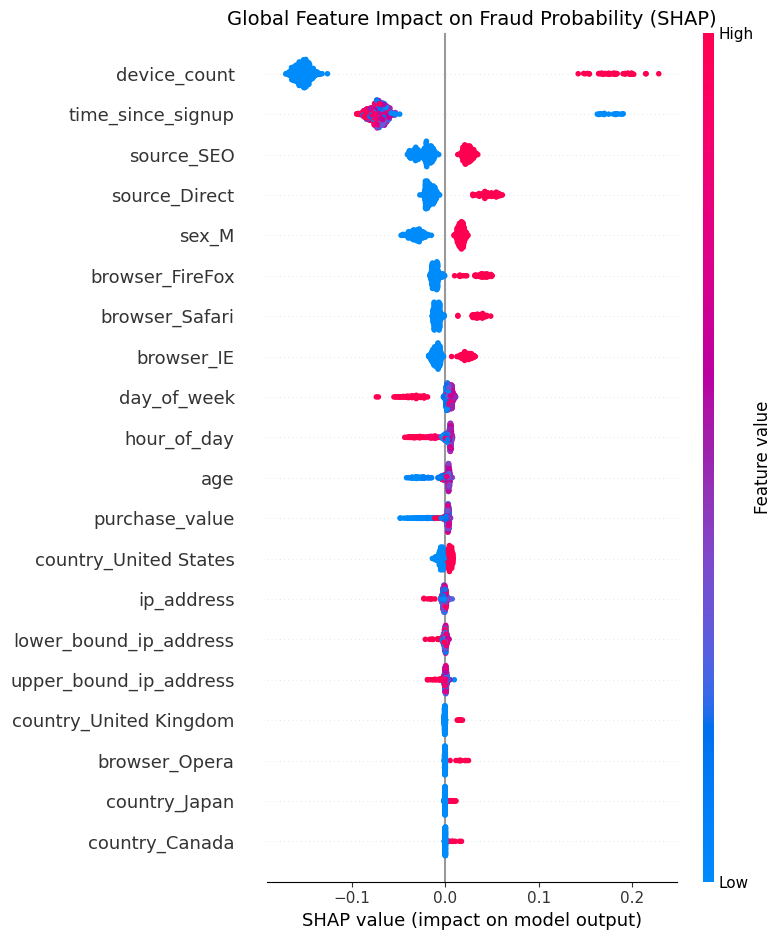

Success! The SHAP plot has been saved smoothly.


In [7]:
import os
import shap
import matplotlib.pyplot as plt

# 1. Initialize SHAP Explainer using your loaded model
explainer = shap.TreeExplainer(model)

# 2. Select a stable evaluation sample from your test dataset (X_test)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# 3. Handle SHAP shape formatting safely
if isinstance(shap_values, list):
    shap_data = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_data = shap_values[:, :, 1]
else:
    shap_data = shap_values

# 4. Generate the Global Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_data, X_sample, show=False)
plt.title("Global Feature Impact on Fraud Probability (SHAP)", fontsize=14)
plt.tight_layout()

# 🔥 THE FIX: Explicitly create the missing directory path before saving
output_dir = "../reports/figures"
os.makedirs(output_dir, exist_ok=True)

# 5. Save and display the plot perfectly
plt.savefig(f"{output_dir}/shap_global_summary.png", dpi=300)
plt.show()
print("Success! The SHAP plot has been saved smoothly.")